In [1]:
# ============================================================
# Notebook setup: run this before everything
# ============================================================

%load_ext autoreload
%autoreload 2

# Control figure size
figsize=(14, 4)

from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
from util import util
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import os

# Load data
data_folder = os.path.join('..', 'data', 'nab')
file_name = os.path.join('realKnownCause', 'nyc_taxi.csv')
data, labels, windows = util.load_series(file_name, data_folder)

# Train and validation end
train_end = pd.to_datetime('2014-10-24 00:00:00')
val_end = pd.to_datetime('2014-12-10 00:00:00')

# Cost model parameters
c_alrm = 1 # Cost of investigating a false alarm
c_missed = 10 # Cost of missing an anomaly
c_late = 5 # Cost for late detection

# Build a cost model
cmodel = util.ADSimpleCostModel(c_alrm, c_missed, c_late)

# Separate the training data
data_tr = data[data.index < train_end]

# Apply a sliding window
wdata = util.sliding_window_1D(data, wlen=10)

# Sequence Input in KDE

## Sequence Input in KDE

**Can we take sequence input into account in KDE?**

There is straightforward approach, using _multivariate_ KDE

* Treat each sequence as a _vector variable_
* Learn an estimator as usual

**Individual _sequences_ in the new dataset are treated as _independent_:**

* This is due to the basic assumptions behind KDE
* In practice, for a sufficiently high window length
* ...The dependencies become _negligible_

**Does it sound familiar?**

This is simply the [Markov property](https://en.wikipedia.org/wiki/Markov_property)!

## Picking a Window Length

**This suggests a way to select the window length**

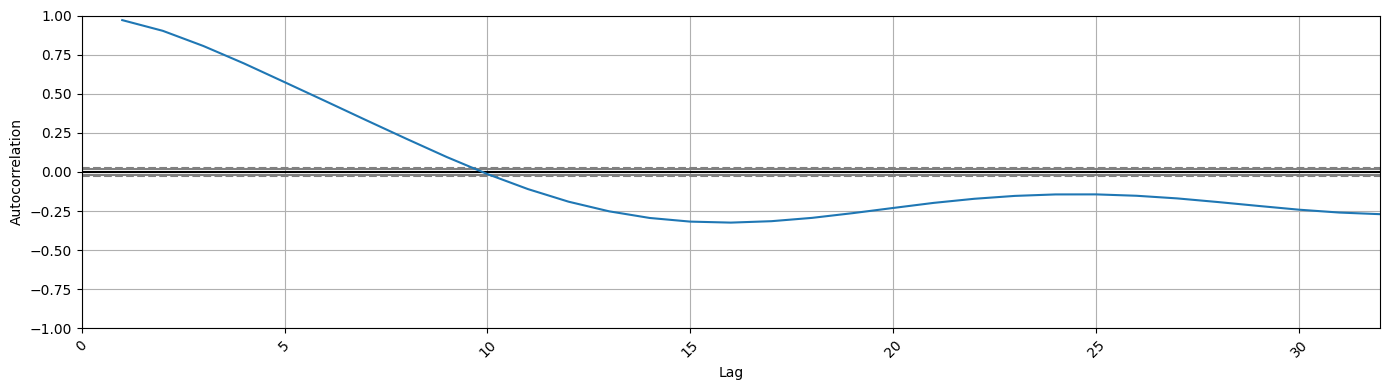

In [3]:
util.plot_autocorrelation(data, max_lag=32, figsize=figsize)

I.e. we end the window where the correlation becomes too low (e.g. 10 in our case)

## Bandwidth Choice in Multivariate KDE

**We now need to learn our multivariate KDE estimator**

For multivariate KDE, the process of choosing the bandwidth becomes more complex because the data is multidimensional, and the simple univariate "rule of thumb" for bandwidth selection no longer applies. Instead, we use a more general approach based on likelihood maximization.

**The basic intuition is that a good bandwidth**

...Will make the actual data register as _more likely_

* Therefore we can pick a _validation set_
* ...And tune the bandwidth for _maximum likelihood_

To avoid overfitting, there should be _no overlap with the training data_

## Bandwidth Choice in Multivariate KDE

**Formally, let $x$ be a _validation_ set of $m$ examples:**
- let $\bar{x}$ be the training set
- let $h$ be the bandwidth (model parameter)
- let $\hat{f}(x_i, \bar{x}_i, h)$ be the KDE density estimator, i.e... the estimated probability of $x_i$ given training set $\bar{x}$ and bandwidth $h$

Assuming independent observations, their _estimated probability_ is given by:

$$L(h, x, \bar{x}) = \prod_{i=1}^m \hat{f}(x_i, \bar{x}_i, h)$$

This is a called a _likelihood function_

* The main input of are the _model parameters_ ($h$ in our case)
* $\hat{f}$ is the density estimator (which outputs a probability)
* $\bar{x}$ the training set


## Bandwidth Choice in Multivariate KDE

KDE never changed — only how we choose the bandwidth did.
We now pick the bandwidth that makes unseen data most probable, instead of relying on heuristics that break in high dimensions.

Meaning:

Take each validation point $x_i$.
Compute its density using KDE trained on $\bar{x}$ and bandwidth $h$
Multiply them all together

Intuition: If a bandwidth is good, it should:
- Assign high density to real data
- Assign low density to unlikely regions
So the best $h$ makes the observed validation data most probable.

**We can then choose $h$ so as to _maximize the likelihood_**

Meaning that the training problem is given by:

$$\mathop{\arg\max}_{h} \mathbb{E}_{x \sim f(x), \bar{x} \sim f(x)}\left[ L(h, x, \bar{x})\right]$$

* Where $f(x)$ is the true distribution

**As many training problem, it cannot be solved in an exact fashion**

* Instead we will approximate $\mathbb{E}$ by sampling multiple $x$ and $\bar{x}$
* ...I.e. multiple validation and training sets
* Then we pick the bandwidth $h^*$ leading to the maximum average likelihood

In a pinch, we could even use a single $x, \bar{x}$ pair

## Bandwidth Choice in Multivariate KDE

**A simple approach consist in combining _grid search_**

* It's the same approach that we used for optimizing the threshold
* scikit learn provides a convenient implementation
* ...Which resorts to cross-fold validation to define $x, \bar{x}$

First, we separate the training set as usual:

In [4]:
wdata_tr = wdata[wdata.index < train_end]

Then we specify the values we want to consider for each parameter:

In [5]:
params = {'bandwidth': np.linspace(400, 800, 20)}

## Training Multivariate KDE

**Finally, we can run the grid search routine**

In [6]:
gs_kde = GridSearchCV(KernelDensity(kernel='gaussian'), params, cv = 5)
gs_kde.fit(wdata_tr)
gs_kde.best_params_

{'bandwidth': np.float64(568.421052631579)}

* `cv` is the number of folds
* After training, `GridSearchCV` acts as a proxy for the best estimator

**This is an _expensive operation_**

* We need to test multiple bandwidth values
* For each one, we need to perform cross-validation
* ...And finally _adding dimensions makes KDE slower_

## Sequences via Multivariate KDE

**Now we can use the best estimator to generate the alarm signal**

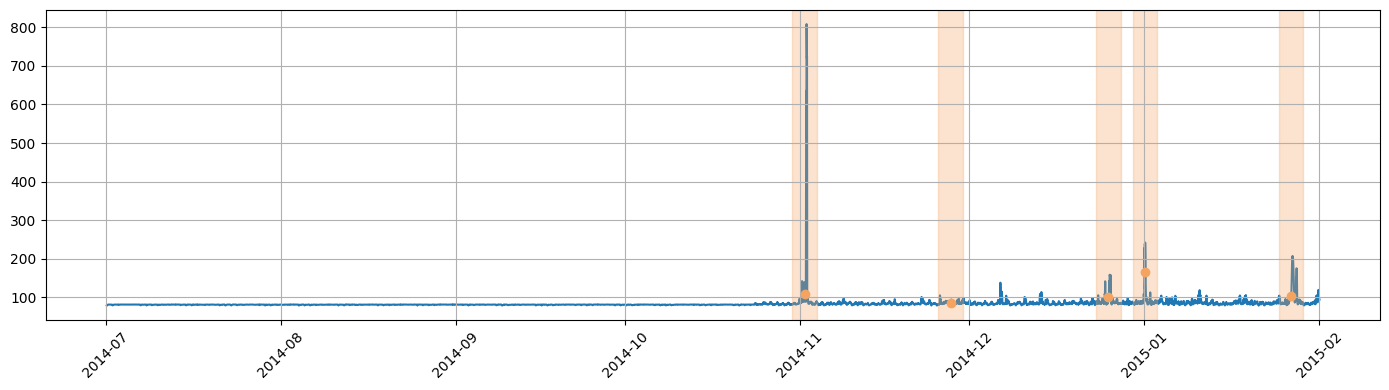

In [7]:
ldens = gs_kde.score_samples(wdata)
signal = pd.Series(index=wdata.index, data=-ldens)
util.plot_series(signal, labels, windows, figsize=figsize)

* The signal seems _visibly better_ than before (but a bit noisy).

The reason why is that now we are taking into account the sequence information, so the density estimates are more accurate. Using a sequence instead of one point means that KDE is fit using this pseudoalgorithm:
- For each sequence in the training set
- Treat it as a vector in a high-dimensional space
- Fit the KDE estimator in that space


## Threshold Optimization

**Finally, we can do threshold optimization as usual**

In [8]:
signal_opt = signal[signal.index < val_end]
labels_opt = labels[labels < val_end]
windows_opt = windows[windows['end'] < val_end]
thr_range = np.linspace(50, 200, 100)

best_thr, best_cost = util.opt_thr(signal_opt, labels_opt, windows_opt,  cmodel, thr_range)
print(f'Best threshold: {best_thr:.3f}, corresponding cost: {best_cost:.3f}')

Best threshold: 104.545, corresponding cost: 7.000


Cost on the whole dataset

In [9]:
ctst = cmodel.cost(signal, labels, windows, best_thr)
print(f'Cost on the whole dataset {ctst}')

Cost on the whole dataset 30
